# Cardio Ontology Explorer (Interactive)

This notebook provides an interactive, pandas-friendly exploration of the generated cardiovascular ontology (OWL).

It loads the ontology from the path you specify (default: `/prj/doctoral_letters/guide/data/cardio_ontology.owl`) and computes: 
- Global triple statistics
- Counts of Classes, Object Properties, Data Properties, Annotation Properties, Named Individuals
- Population (instance) counts per class (including subclass closure)
- Subclass hierarchy metrics (direct subclass counts)
- Object/Data property usage counts, domains, and ranges
- Individual summaries (types, labels, synonym counts, outgoing assertions)
- Quick search utilities over labels & synonyms

Optional: adjust `ONTOLOGY_PATH` below to inspect a different OWL file.
All outputs are standard pandas DataFrames for convenient filtering/sorting.

In [1]:
# Configuration: set the path to the ontology you want to explore
ONTOLOGY_PATH = '/home/pwiesenbach/CardioGuidelinesGraph/cardio_ontology.owl'  # Change if needed

from pathlib import Path
import rdflib
import pandas as pd
from collections import defaultdict, Counter
from typing import Set, Dict, Iterable
from rdflib.namespace import RDF, RDFS, OWL, SKOS

path = Path(ONTOLOGY_PATH)
if not path.exists():
    raise FileNotFoundError(f'Ontology file not found at: {path}')
print(f'Loading ontology from: {path}')
g = rdflib.Graph()
g.parse(path)
print(f'Total triples: {len(g):,}')

Loading ontology from: /home/pwiesenbach/CardioGuidelinesGraph/cardio_ontology.owl
Total triples: 33,259
Total triples: 33,259


## Core Sets Extraction

We extract sets of classes, properties, individuals, and annotation properties for downstream statistics.

In [2]:
# Helper: collect entities by rdf:type
def collect_by_type(graph, rdf_type):
    return {s for s in graph.subjects(RDF.type, rdf_type)}

classes: Set = collect_by_type(g, OWL.Class) | collect_by_type(g, RDFS.Class)
object_properties: Set = collect_by_type(g, OWL.ObjectProperty)
data_properties: Set = collect_by_type(g, OWL.DatatypeProperty)
annotation_properties: Set = collect_by_type(g, OWL.AnnotationProperty)
named_individuals: Set = collect_by_type(g, OWL.NamedIndividual)

print(f'Classes: {len(classes):,}')
print(f'Object Properties: {len(object_properties):,}')
print(f'Data Properties: {len(data_properties):,}')
print(f'Annotation Properties: {len(annotation_properties):,}')
print(f'Named Individuals: {len(named_individuals):,}')

Classes: 34
Object Properties: 17
Data Properties: 13
Annotation Properties: 0
Named Individuals: 6,413


## Labels & Utility Functions

Functions to retrieve labels, comments, synonyms, subclass relations, and compute subclass closure for population counts.

In [3]:
def get_first(graph, subj, pred_list):
    for p in pred_list:
        obj = next(graph.objects(subj, p), None)
        if obj: return str(obj)
    return None

def get_labels(subj):
    return [str(o) for o in g.objects(subj, RDFS.label)]

def get_comment(subj):
    c = get_first(g, subj, [RDFS.comment])
    return c

def get_synonyms(subj):
    return [str(o) for o in g.objects(subj, SKOS.altLabel)]

# Build subclass adjacency (direct)
subclass_of_map: Dict = defaultdict(set)  # child -> parents
children_map: Dict = defaultdict(set)     # parent -> children
for c in classes:
    for parent in g.objects(c, RDFS.subClassOf):
        subclass_of_map[c].add(parent)
        children_map[parent].add(c)

def descendants(cls):
    # BFS over subclass edges to get all descendant classes (including cls)
    visited = set([cls])
    frontier = [cls]
    while frontier:
        nxt = []
        for node in frontier:
            for child in children_map.get(node, []):
                if child not in visited:
                    visited.add(child)
                    nxt.append(child)
        frontier = nxt
    return visited

# Pre-compute individuals typed to each class (direct)
direct_instances: Dict = defaultdict(set)
for ind in named_individuals:
    for cls in g.objects(ind, RDF.type):
        if cls in classes:
            direct_instances[cls].add(ind)

def population_with_subclasses(cls):
    total = set()
    for d in descendants(cls):
        total |= direct_instances.get(d, set())
    return total

print('Utility functions initialized.')

Utility functions initialized.


## Class Statistics DataFrame

Includes: URI, preferred label, number of direct subclasses, population (including subclasses), direct population, synonym count.

In [4]:
class_rows = []
for cls in classes:
    labels = get_labels(cls)
    label = labels[0] if labels else cls.n3(g.namespace_manager)
    syns = get_synonyms(cls)
    direct_subs = len(children_map.get(cls, []))
    direct_pop = len(direct_instances.get(cls, set()))
    total_pop = len(population_with_subclasses(cls))
    class_rows.append({
        'class': str(cls),
        'label': label,
        'direct_subclasses': direct_subs,
        'direct_population': direct_pop,
        'total_population': total_pop,
        'synonym_count': len(syns),
    })
classes_df = pd.DataFrame(class_rows)
classes_df.sort_values('total_population', ascending=False).head(10)

,class,label,direct_subclasses,direct_population,total_population,synonym_count
33,http://dieterich-lab.org/ontologies/cardioguid...,Condition,1,2550,2550,4
15,http://dieterich-lab.org/ontologies/cardioguid...,ClinicalAction,7,1757,1757,4
0,http://dieterich-lab.org/ontologies/cardioguid...,Medication,0,957,957,0
4,http://dieterich-lab.org/ontologies/cardioguid...,PatientPhenotype,1,906,906,4
30,http://dieterich-lab.org/ontologies/cardioguid...,Purpose,0,79,79,0
18,http://dieterich-lab.org/ontologies/cardioguid...,EvidenceStatement,2,0,58,3
2,http://dieterich-lab.org/ontologies/cardioguid...,GuidelineRecommendation,0,58,58,0
19,http://dieterich-lab.org/ontologies/cardioguid...,WorkflowStep,0,55,55,0
1,http://dieterich-lab.org/ontologies/cardioguid...,EvidenceSource,0,38,38,3
6,http://dieterich-lab.org/ontologies/cardioguid...,Guideline,0,13,13,0


## Object & Data Property Statistics

We compute usage counts (number of triples asserting each property) and gather domain/range info.

In [18]:
def collect_domain_range(prop_set):
    """Return DataFrame with domain/range and usage statistics for given properties.
    Handles empty property sets gracefully.
    """
    rows = []
    usage_counter = Counter()
    if not prop_set:
        # Return an empty DataFrame with expected columns so downstream code works
        return pd.DataFrame(columns=[
            'property','label','usage_count','domains','ranges'
        ])
    # Iterate triples once (could be optimized globally if needed)
    for s, p, o in g:  # iterate all triples once for usage
        if p in prop_set:
            usage_counter[p] += 1
    for prop in prop_set:
        domains = {str(o) for o in g.objects(prop, RDFS.domain)}
        ranges = {str(o) for o in g.objects(prop, RDFS.range)}
        labels = get_labels(prop)
        rows.append({
            'property': str(prop),
            'label': labels[0] if labels else prop.n3(g.namespace_manager),
            'usage_count': usage_counter.get(prop, 0),
            'domains': '; '.join(sorted(domains)) or '',
            'ranges': '; '.join(sorted(ranges)) or '',
        })
    df = pd.DataFrame(rows)
    if 'usage_count' in df.columns:
        df = df.sort_values('usage_count', ascending=False)
    return df

object_props_df = collect_domain_range(object_properties)
data_props_df = collect_domain_range(data_properties)


In [19]:
data_props_df

,property,label,usage_count,domains,ranges
0,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetValue,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
1,http://dieterich-lab.org/ontologies/cardioguid...,hasFrequency,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
2,http://dieterich-lab.org/ontologies/cardioguid...,hasAdjustmentInstruction,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
3,http://dieterich-lab.org/ontologies/cardioguid...,hasSourceText,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
4,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetOperator,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
5,http://dieterich-lab.org/ontologies/cardioguid...,pageNumber,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#integer
6,http://dieterich-lab.org/ontologies/cardioguid...,hasTitrationSchedule,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
7,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetUnit,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
8,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetDose,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
9,http://dieterich-lab.org/ontologies/cardioguid...,hasSnomedId,0,,http://www.w3.org/2001/XMLSchema#string


Display top Data Properties by usage.

In [20]:
data_props_df

,property,label,usage_count,domains,ranges
0,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetValue,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
1,http://dieterich-lab.org/ontologies/cardioguid...,hasFrequency,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
2,http://dieterich-lab.org/ontologies/cardioguid...,hasAdjustmentInstruction,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
3,http://dieterich-lab.org/ontologies/cardioguid...,hasSourceText,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
4,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetOperator,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
5,http://dieterich-lab.org/ontologies/cardioguid...,pageNumber,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#integer
6,http://dieterich-lab.org/ontologies/cardioguid...,hasTitrationSchedule,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
7,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetUnit,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
8,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetDose,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
9,http://dieterich-lab.org/ontologies/cardioguid...,hasSnomedId,0,,http://www.w3.org/2001/XMLSchema#string


## Top Object Properties by Usage (Bar Plot)

Visualization of the most used object properties.

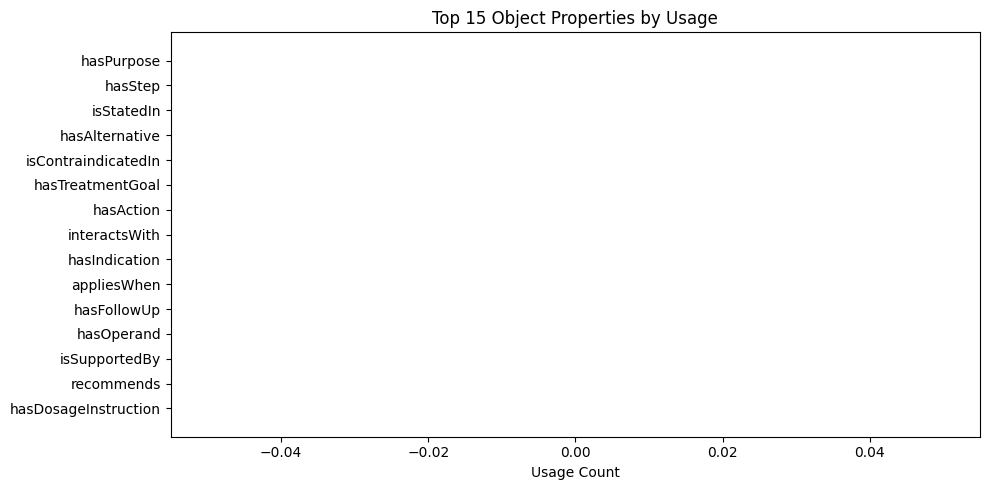

In [15]:
top_n = 15
if not object_props_df.empty:
    top_object_props = object_props_df.head(top_n)
    plt.figure(figsize=(10,5))
    plt.barh(top_object_props['label'][::-1], top_object_props['usage_count'][::-1])
    plt.xlabel('Usage Count')
    plt.title(f'Top {top_n} Object Properties by Usage')
    plt.tight_layout()
    plt.show()
else:
    print("No object properties found to plot.")

## Top Data Properties by Usage (Bar Plot)

Visualization of the most used data properties.

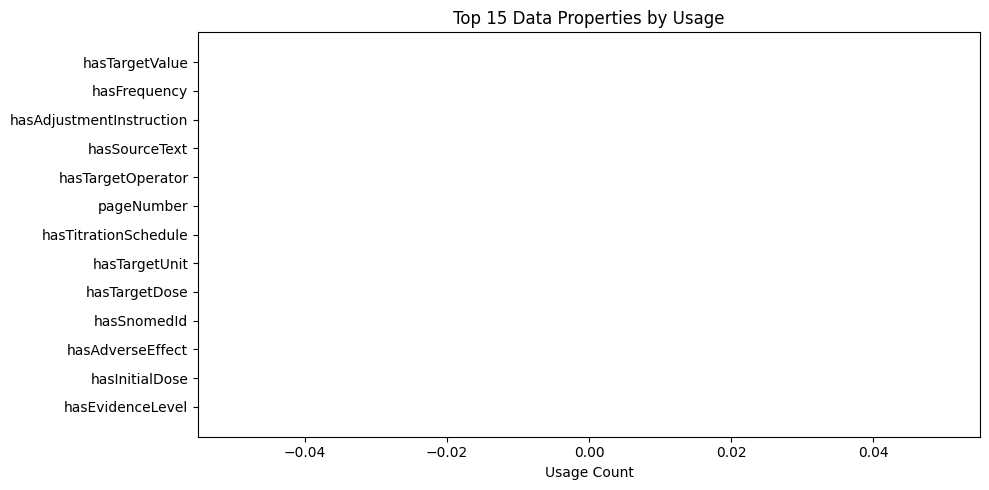

In [14]:
top_n = 15
if not data_props_df.empty:
    top_data_props = data_props_df.head(top_n)
    plt.figure(figsize=(10,5))
    plt.barh(top_data_props['label'][::-1], top_data_props['usage_count'][::-1])
    plt.xlabel('Usage Count')
    plt.title(f'Top {top_n} Data Properties by Usage')
    plt.tight_layout()
    plt.show()
else:
    print("No data properties found to plot.")

## Individual (Named Entity) Summary

We summarize each named individual: labels, types, synonym count, outgoing object/data assertions.

In [10]:
ind_rows = []
object_prop_set = set(object_properties)
data_prop_set = set(data_properties)
for ind in named_individuals:
    labels = get_labels(ind)
    syns = get_synonyms(ind)
    types = [str(t) for t in g.objects(ind, RDF.type) if t in classes]  # filter to ontology classes
    obj_assertions = 0
    data_assertions = 0
    for p,o in g.predicate_objects(ind):
        if p in object_prop_set: obj_assertions += 1
        if p in data_prop_set: data_assertions += 1
    ind_rows.append({
        'individual': str(ind),
        'label': labels[0] if labels else ind.n3(g.namespace_manager),
        'types': '; '.join(types),
        'synonym_count': len(syns),
        'object_assertions': obj_assertions,
        'data_assertions': data_assertions,
    })
individuals_df = pd.DataFrame(ind_rows)
individuals_df.head(10)

,individual,label,types,synonym_count,object_assertions,data_assertions
0,http://snomed.info/id/106153001,Third cranial nerve finding,http://dieterich-lab.org/ontologies/cardioguid...,1,0,0
1,http://snomed.info/id/8185002,Panic disorder with agoraphobia AND moderate p...,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
2,http://snomed.info/id/225220004,Communication interventions,http://dieterich-lab.org/ontologies/cardioguid...,1,0,0
3,http://snomed.info/id/424240003,Product containing terbinafine in topical dosa...,http://dieterich-lab.org/ontologies/cardioguid...,2,0,0
4,http://snomed.info/id/306322009,Referral to cardiac rehabilitation nurse,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
5,http://snomed.info/id/81511006,Basic learning problem in language,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
6,http://snomed.info/id/89989005,Deferred diagnosis on Axis V,http://dieterich-lab.org/ontologies/cardioguid...,1,0,0
7,http://snomed.info/id/71909003,Acute renal failure following molar AND/OR ect...,http://dieterich-lab.org/ontologies/cardioguid...,1,0,0
8,http://snomed.info/id/315740005,[V]Personal history of other lymphatic or hema...,http://dieterich-lab.org/ontologies/cardioguid...,6,0,0
9,http://snomed.info/id/433276002,Family history of atrial fibrillation (situation),http://dieterich-lab.org/ontologies/cardioguid...,1,0,0


## Search Utilities

Convenience functions to search labels & synonyms of classes or individuals.

In [11]:
def search_entities(query: str, in_classes=True, in_individuals=True, limit=25):
    q = query.lower()
    results = []
    if in_classes:
        for cls in classes:
            labels = get_labels(cls)
            syns = get_synonyms(cls)
            text = ' '.join(labels + syns).lower()
            if q in text:
                results.append(('class', labels[0] if labels else str(cls), str(cls)))
    if in_individuals:
        for ind in named_individuals:
            labels = get_labels(ind)
            syns = get_synonyms(ind)
            text = ' '.join(labels + syns).lower()
            if q in text:
                results.append(('individual', labels[0] if labels else str(ind), str(ind)))
    return pd.DataFrame(results[:limit], columns=['type','label','uri'])

# Example search (modify the query)
search_entities('heart')

,type,label,uri
0,class,CardiovascularDisease,http://dieterich-lab.org/ontologies/cardioguid...
1,class,HeartFailureTherapy,http://dieterich-lab.org/ontologies/cardioguid...
2,class,CardiacRehabilitation,http://dieterich-lab.org/ontologies/cardioguid...
3,individual,Chronic heart failure,http://snomed.info/id/48447003
4,individual,Framingham coronary heart disease 10 year risk...,http://snomed.info/id/165211005
5,individual,Four dimensional ultrasound imaging of heart,http://snomed.info/id/51469006
6,individual,New York Heart Association classification of h...,http://snomed.info/id/366743000
7,individual,Myocardial infarction (& [acute]) or coronary ...,http://snomed.info/id/266288001
8,individual,Intermediate epidermolysis bullosa simplex wit...,http://snomed.info/id/1177176009
9,individual,Obesity due to CEP19 deficiency,http://snomed.info/id/783549006


## Top Classes by Population (Bar Plot)

Simple visualization of the most populated classes (including descendants).

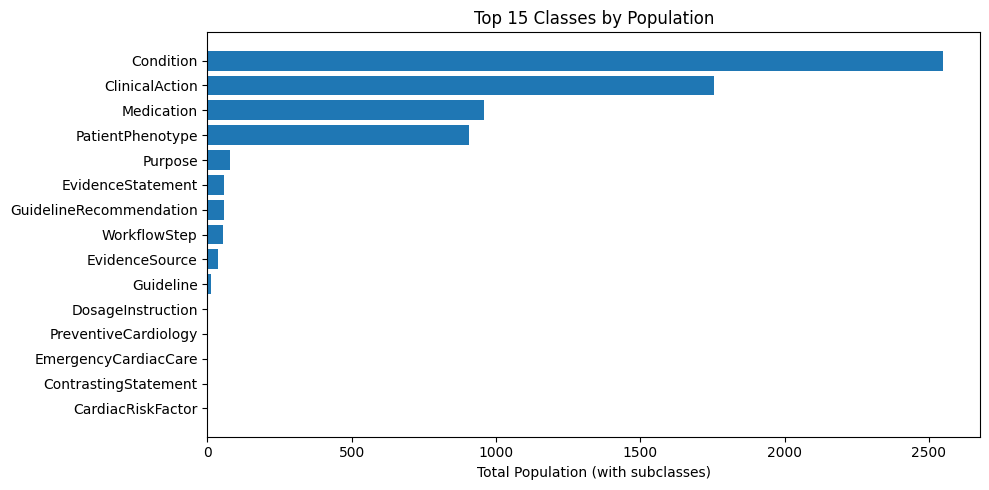

In [12]:
import matplotlib.pyplot as plt
top_n = 15
top_classes = classes_df.sort_values('total_population', ascending=False).head(top_n)
plt.figure(figsize=(10,5))
plt.barh(top_classes['label'][::-1], top_classes['total_population'][::-1])
plt.xlabel('Total Population (with subclasses)')
plt.title(f'Top {top_n} Classes by Population')
plt.tight_layout()
plt.show()

## Summary

You now have: `classes_df`, `object_props_df`, `data_props_df`, `individuals_df` and helper `search_entities()`.
Use standard pandas filtering, e.g.:

```python
classes_df[classes_df.total_population > 0].sort_values('total_population', ascending=False).head(20)
```

Feel free to extend with reasoning or export subsets using `to_csv()`.